# Reliability plots for Szucs and Ioannidis data

In [3]:
# read csv into numpy array
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.io import loadmat

# df = pd.read_csv('../data/nudges.csv')
# list(enumerate(df.columns))

mat = loadmat('../data/psych.mat')
data = mat['D'][0,0]

raw_names = data['JournalNames'].flatten()
journal_lookup = [n.item() if hasattr(n, 'item') else n for n in raw_names]

raw_codes = data['JournalTypes']['arr'].item()
journal_codes = raw_codes.flatten().astype(int)

df = pd.DataFrame({
    'tvalues': data['tvalues'].flatten(),
    'df': data['df'].flatten()
})

# calculate 2 sided p values from t values and degrees of freedom
df['p_value'] = 2 * stats.t.sf(np.abs(df['tvalues']), df['df'])

# find duplicate t-values
type(df['tvalues'])
duplicate_tvals = df['tvalues'][df['tvalues'].duplicated(keep=False)]

# list the unique duplicate t-values and their counts
# duplicate_tval_counts = duplicate_tvals.value_counts()
# print(duplicate_tval_counts)

# want to randomize the t-values that are rounded

In [4]:
# df['t_stat'] = df['cohens_d'] / np.sqrt(df['variance_d'])
# df['p_value']  = stats.t.cdf(-df['t_stat'], df['n_comparison'] - 2)
# df['p_value']

# subset data to only include rows where p_value < 0.05
significant_df = df[df['p_value'] < 0.025]
# multiply all p values by 40
significant_df['p_value'] = significant_df['p_value'] * 40
len(significant_df)
len(df)

# df = df[df['p_value'] < 0.025]
# df['p_value'] = df['p_value'] * 40

26841

In [6]:
import matplotlib.pyplot as plt
m = len(df)
lam = 1 - m ** (-1/5)
pi_hat_0 = np.mean(df['p_value'] > lam) / (1 - lam)
pi_hat_0

np.float64(0.2689221895601252)

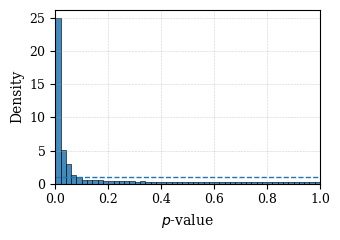

In [8]:
plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "font.family": "serif",
    "text.usetex": False
})

plt.figure(figsize=(3.5, 2.5))

plt.hist(
    df["p_value"],
    bins=50,
    density=True,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.5
)

# Uniform reference
plt.axhline(1.0, linestyle="--", linewidth=1)

plt.xlabel(r"$p$-value")
plt.ylabel("Density")

plt.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)
plt.xlim(0, 1)

plt.tight_layout()
plt.savefig("pvalue_distribution.png", bbox_inches="tight", dpi = 800)
plt.show()

## P-Value Calibration Plot

             p_bin     p_min     p_max    p_mean  count  p_bin_length  \
0  (-0.001, 0.111]  0.000000  0.111010  0.017142  19197         0.112   
1   (0.111, 0.222]  0.111133  0.222222  0.161447   1567         0.111   
2   (0.222, 0.333]  0.222347  0.333285  0.275683   1090         0.111   
3   (0.333, 0.444]  0.333812  0.444372  0.387383    927         0.111   
4   (0.444, 0.556]  0.444599  0.555244  0.498834    856         0.112   
5   (0.556, 0.667]  0.555595  0.666654  0.609377    825         0.111   
6   (0.667, 0.778]  0.666902  0.777741  0.723274    805         0.111   
7   (0.778, 0.889]  0.777819  0.888847  0.832967    749         0.111   
8     (0.889, 1.0]  0.889107  1.000000  0.944544    825         0.111   

   true_nulls_hat  proportion_true_nulls bin_start bin_end  
0      801.597657               0.041756    -0.001   0.111  
1      794.440535               0.506982     0.111   0.222  
2      794.440535               0.728845     0.222   0.333  
3      794.440535        

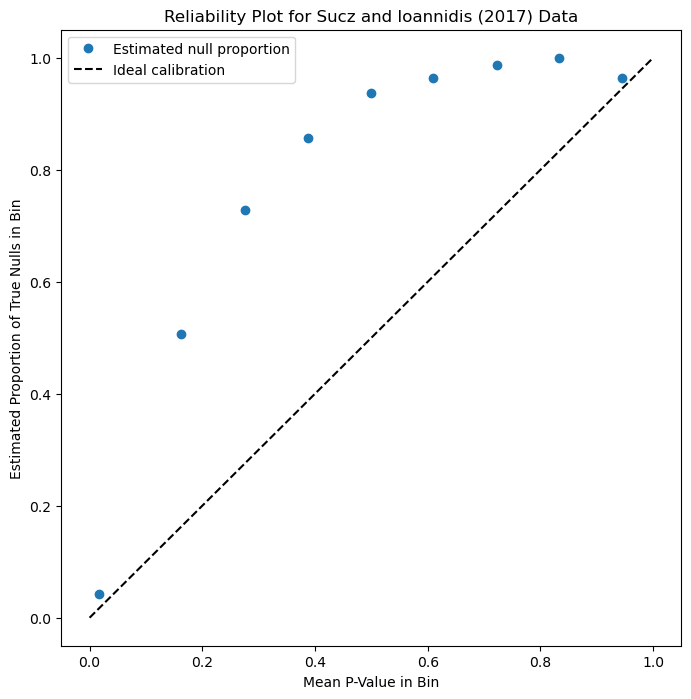

In [125]:
# p-value bins
bins = np.linspace(0, 1, 10)

# put p-values into bins
df["p_bin"] = pd.cut(df["p_value"], bins=bins, include_lowest=True, right=True)

# summarize within each p-bin
p_bin_stats = (
    df.groupby("p_bin", observed=False)
      .agg(
          p_min=("p_value", "min"),
          p_max=("p_value", "max"),
          p_mean=("p_value", "mean"),
          count=("p_value", "size")
      )
      .reset_index()
)

# total number of tests
m = len(df)

# empirical p-range length actually occupied within each bin -- actual bin length from the cuts
p_bin_stats["p_bin_length"] = p_bin_stats["p_bin"].apply(lambda x: x.right - x.left)

# expected number of nulls in that interval under Storey's estimate
p_bin_stats["true_nulls_hat"] = pi_hat_0 * m * p_bin_stats["p_bin_length"]

# estimated proportion of true nulls in each occupied bin
p_bin_stats["proportion_true_nulls"] = np.minimum(
    p_bin_stats["true_nulls_hat"] / p_bin_stats["count"],
    1.0
)

p_bin_stats["bin_start"] = p_bin_stats["p_bin"].apply(lambda x: x.left)
p_bin_stats["bin_end"] = p_bin_stats["p_bin"].apply(lambda x: x.right)

print(p_bin_stats)

# reliability plot
plt.figure(figsize=(8, 8))

plt.plot(
    p_bin_stats["p_mean"],
    p_bin_stats["proportion_true_nulls"],
    "o",
    label="Estimated null proportion"
)

plt.plot([0, 1], [0, 1], "k--", label="Ideal calibration")

plt.xlabel("Mean P-Value in Bin")
plt.ylabel("Estimated Proportion of True Nulls in Bin")
plt.title("Reliability Plot for Sucz and Ioannidis (2017) Data")

plt.legend()
plt.show()

## Q-Value Calibration Plot

In [128]:
# make q-values from p-values
def qvalues(pvals, lam=0.5):
    pvals = np.asarray(pvals)
    m = len(pvals)

    # sort p-values
    order = np.argsort(pvals)
    p_sorted = pvals[order]

    # estimate pi0
    pi0 = np.mean(pvals > lam) / (1 - lam)
    pi0 = min(pi0, 1.0)

    # compute initial q-values (i.e. pFDRs for each p-value)
    qvals = m * p_sorted / np.arange(1, m + 1)

    # enforce monotonicity by taking minimum at each step
    qvals = np.minimum.accumulate(qvals[::-1])[::-1]
    qvals = np.minimum(qvals, 1.0)

    # return in original order
    # q_original = np.empty_like(qvals)
    # q_original[order] = qvals

    q_original = qvals[np.argsort(order)]

    return q_original

df['q_value'] = qvalues(df['p_value'])

             q_bin     p_min     p_max    p_mean    q_mean  count  \
0  (-0.001, 0.111]  0.000000  0.075852  0.013643  0.024890  18327   
1   (0.111, 0.222]  0.075933  0.166162  0.114187  0.158695   1761   
2   (0.222, 0.333]  0.166673  0.263066  0.212672  0.276030   1108   
3   (0.333, 0.444]  0.263307  0.366655  0.313156  0.387466    948   
4   (0.444, 0.556]  0.366728  0.476637  0.420666  0.499451    891   
5   (0.556, 0.667]  0.477476  0.594622  0.535728  0.611723    913   
6   (0.667, 0.778]  0.595470  0.719638  0.656569  0.722110    889   
7   (0.778, 0.889]  0.719820  0.854042  0.786533  0.833557    956   
8     (0.889, 1.0]  0.854270  1.000000  0.928994  0.946976   1048   

   p_bin_length  true_nulls_hat  proportion_true_nulls q_bin_start q_bin_end  
0      0.075852      542.879981               0.029622      -0.001     0.111  
1      0.090229      645.780049               0.366712       0.111     0.222  
2      0.096394      689.901575               0.622655       0.222     0

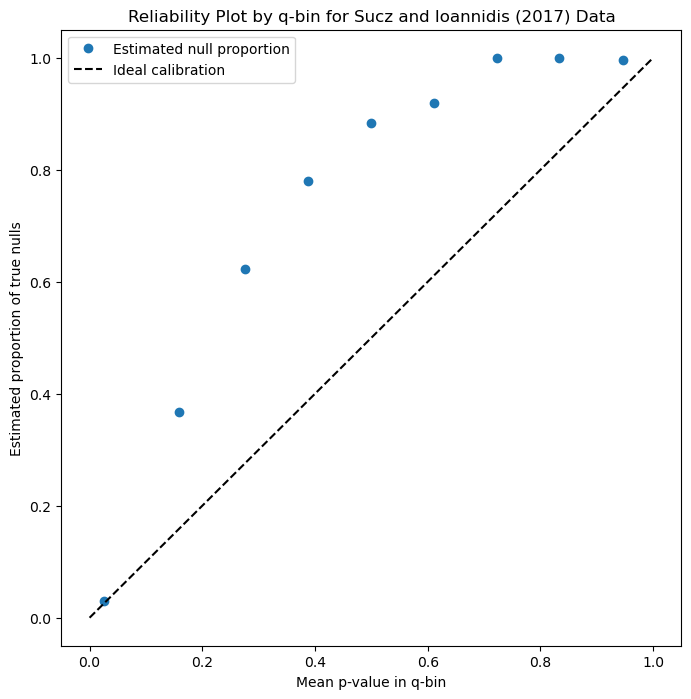

In [129]:
# q-value bins
bins = np.linspace(0, 1, 10)

# put q-values into bins
df["q_bin"] = pd.cut(df["q_value"], bins=bins, include_lowest=True, right=True)

# summarize p-values within each q-bin
q_bin_stats = (
    df.groupby("q_bin", observed=False)
      .agg(
          p_min=("p_value", "min"),
          p_max=("p_value", "max"),
          p_mean=("p_value", "mean"),
          q_mean=("q_value", "mean"),
          count=("p_value", "size")
      )
      .reset_index()
)

# empirical p-range length induced by each q-bin
q_bin_stats["p_bin_length"] = q_bin_stats["p_max"] - q_bin_stats["p_min"]

# expected number of nulls in that p-interval under Storey's estimate
q_bin_stats["true_nulls_hat"] = pi_hat_0 * m * q_bin_stats["p_bin_length"]

# estimated null proportion within the q-bin
q_bin_stats["proportion_true_nulls"] = np.minimum(
    q_bin_stats["true_nulls_hat"] / q_bin_stats["count"],
    1.0
)

q_bin_stats["q_bin_start"] = q_bin_stats["q_bin"].apply(lambda x: x.left)
q_bin_stats["q_bin_end"] = q_bin_stats["q_bin"].apply(lambda x: x.right)

print(q_bin_stats)

plt.figure(figsize=(8, 8))

plt.plot(q_bin_stats["q_mean"], q_bin_stats["proportion_true_nulls"], "o", label="Estimated null proportion")

plt.plot([0, 1], [0, 1], "k--", label="Ideal calibration")

plt.xlabel("Mean p-value in q-bin")
plt.ylabel("Estimated proportion of true nulls")
plt.title("Reliability Plot by q-bin for Sucz and Ioannidis (2017) Data")

plt.legend()
plt.show()

## lfdr Calibration Plot

In [130]:
%reload_ext autoreload
%autoreload 2
from npeb import Grenander, local_fdr

In [ ]:
# check and see if there are duplicates in the p-values
print(f"Number of unique p-values: {len(df['p_value'].unique())}")
print(f"Total number of p-values: {len(df['p_value'])}")

duplicate_pvals = df['p_value'][df['p_value'].duplicated(keep=False)]

# list the unique duplicate p-values and their counts
duplicate_pval_counts = duplicate_pvals.value_counts()
print(duplicate_pval_counts)

# keep only the unique p-values for Grenander fitting
unique_pvals = df['p_value'].unique()
unique_pvals.sort()
unique_pvals
# remove any p-values that are exactly 0 or 1
# unique_pvals = unique_pvals[(unique_pvals > 0) & (unique_pvals < 1)]

# find minimum gap between unique p-values
pval_gaps = np.diff(unique_pvals)
min_gap = np.min(pval_gaps)
print(f"Minimum gap between unique p-values: {min_gap}")

max_gap = np.max(pval_gaps)
print(f"Maximum gap between unique p-values: {max_gap}")

# split the p-values into a training and testing set
# random index for training set
train_idx = np.random.choice(len(unique_pvals), size=int(0.5 * len(unique_pvals)), replace=False)
train_pvals = unique_pvals[train_idx]
test_pvals = unique_pvals[~np.isin(unique_pvals, train_pvals)]

Number of unique p-values: 20393
Total number of p-values: 26841
p_value
1.000000    41
0.043896    16
0.036224    13
0.016459    12
0.037350    12
            ..
0.029120     2
0.023039     2
0.011344     2
0.002799     2
0.000414     2
Name: count, Length: 4018, dtype: int64
Minimum gap between unique p-values: 1.132895415175887e-273
Maximum gap between unique p-values: 0.0019575658449456634


In [141]:
# fit grenander to the unique p-values
gren = Grenander(x_min=-0.1, x_max=1.1)
fhat_split =  gren.fit(train_pvals)
# fhat = gren.fit(unique_pvals)

In [142]:
pi_hat_0_gren = np.mean(test_pvals > 0.5) / (1 - 0.5)
test_lfdr = pi_hat_0_gren / gren.pdf(test_pvals)
test_df = pd.DataFrame({
    'p_value': test_pvals,
    'lfdr': test_lfdr
})

          lfdr_bin     p_min     p_max    p_mean  lfdr_mean  count  \
0  (-0.001, 0.111]  0.000000  0.051298  0.009098   0.059965   6616   
1   (0.111, 0.222]  0.051319  0.074198  0.061706   0.172101    336   
2   (0.222, 0.333]  0.074266  0.100624  0.086796   0.265359    288   
3   (0.333, 0.444]  0.101055  0.149980  0.124097   0.424049    339   
4   (0.444, 0.556]  0.150422  0.183469  0.165654   0.506050    180   
5   (0.556, 0.667]  0.183695  0.243080  0.213866   0.609423    267   
6   (0.667, 0.778]  0.243853  0.348621  0.292263   0.672004    383   
7   (0.778, 0.889]  0.349114  0.384597  0.367152   0.825395    111   
8     (0.889, 1.0]  0.385855  0.993152  0.672579   0.952856   1669   

   p_bin_length  true_nulls_hat  proportion_true_nulls lfdr_bin_start  \
0      0.051298      134.707834               0.020361         -0.001   
1      0.022878       60.078149               0.178804          0.111   
2      0.026359       69.217477               0.240338          0.222   
3      

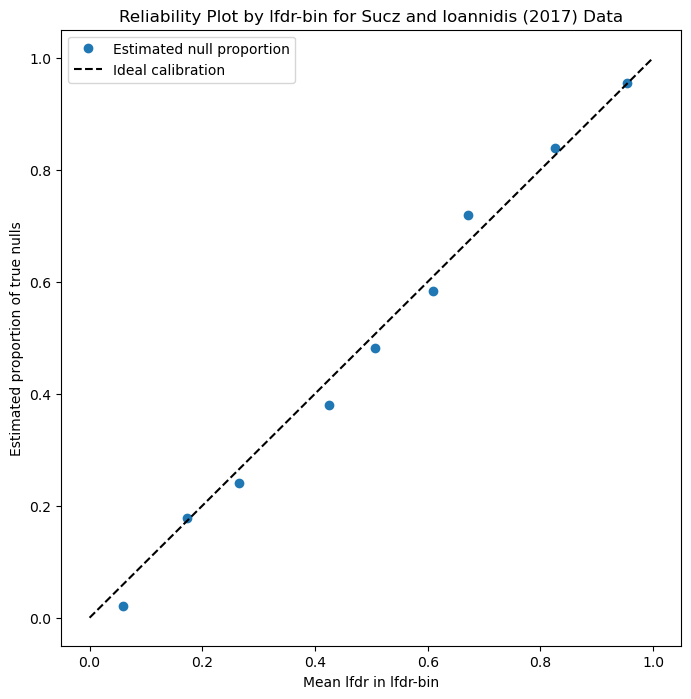

In [143]:
# lfdr bins
bins = np.linspace(0, 1, 10)

# put lfdr  into bins
# df["lfdr_bin"] = pd.cut(df["lfdr"], bins=bins, include_lowest=True, right=True)
test_df["lfdr_bin"] = pd.cut(test_df["lfdr"], bins=bins, include_lowest=True, right=True)

# m = len(df)
m = len(test_df)

# summarize p-values within each lfdr-bin
lfdr_bin_stats = (
    test_df.groupby("lfdr_bin", observed=False)
      .agg(
          p_min=("p_value", "min"),
          p_max=("p_value", "max"),
          p_mean=("p_value", "mean"),
          lfdr_mean=("lfdr", "mean"),
          count=("p_value", "size")
      )
      .reset_index()
)

# empirical p-range length induced by each lfdr-bin
lfdr_bin_stats["p_bin_length"] = lfdr_bin_stats["p_max"] - lfdr_bin_stats["p_min"]

# expected number of nulls in that p-interval under Storey's estimate
lfdr_bin_stats["true_nulls_hat"] = pi_hat_0_gren * m * lfdr_bin_stats["p_bin_length"]

# estimated null proportion within the lfdr-bin
lfdr_bin_stats["proportion_true_nulls"] = np.minimum(
    lfdr_bin_stats["true_nulls_hat"] / lfdr_bin_stats["count"],
    1.0
)

lfdr_bin_stats["lfdr_bin_start"] = lfdr_bin_stats["lfdr_bin"].apply(lambda x: x.left)
lfdr_bin_stats["lfdr_bin_end"] = lfdr_bin_stats["lfdr_bin"].apply(lambda x: x.right)

print(lfdr_bin_stats)

# plot reliability plot for lfdr bins (estimated null proportion vs. mean lfdr in bin)

plt.figure(figsize=(8, 8))

plt.plot(lfdr_bin_stats["lfdr_mean"], lfdr_bin_stats["proportion_true_nulls"], "o", label="Estimated null proportion")

plt.plot([0, 1], [0, 1], "k--", label="Ideal calibration")

plt.xlabel("Mean lfdr in lfdr-bin")
plt.ylabel("Estimated proportion of true nulls")
plt.title("Reliability Plot by lfdr-bin for Sucz and Ioannidis (2017) Data")

plt.legend()
plt.show()

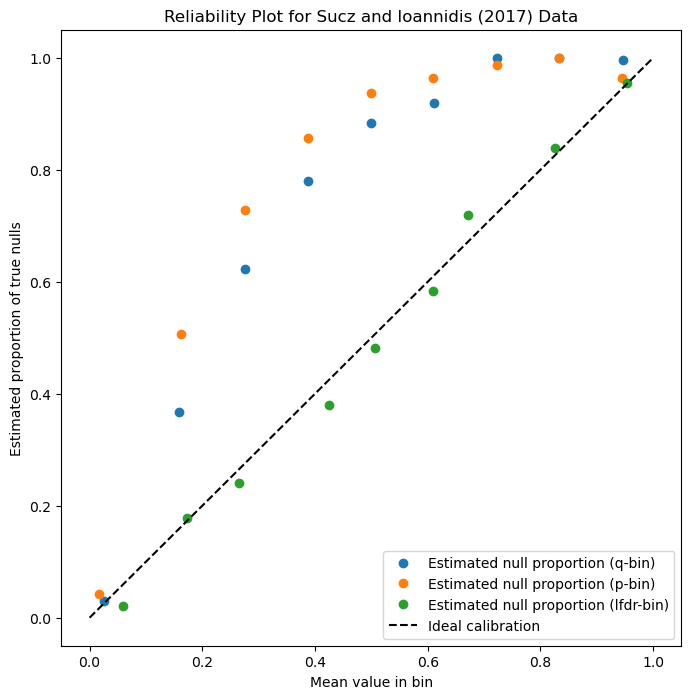

In [144]:
# put all calibration points on one plot
plt.figure(figsize=(8, 8))
plt.plot(q_bin_stats["q_mean"], q_bin_stats["proportion_true_nulls"], "o", label="Estimated null proportion (q-bin)")
plt.plot(p_bin_stats["p_mean"], p_bin_stats["proportion_true_nulls"], "o", label="Estimated null proportion (p-bin)")
plt.plot(lfdr_bin_stats["lfdr_mean"], lfdr_bin_stats["proportion_true_nulls"], "o", label="Estimated null proportion (lfdr-bin)")
# 45-degree reference line
plt.plot([0, 1], [0, 1], "k--", label="Ideal calibration")
plt.xlabel("Mean value in bin")
plt.ylabel("Estimated proportion of true nulls")
plt.title("Reliability Plot for Sucz and Ioannidis (2017) Data")
plt.legend()
plt.show()

In [145]:
# get calibration error
lfdr_bin_stats["calibration_error"] = np.abs(lfdr_bin_stats["proportion_true_nulls"] - lfdr_bin_stats["lfdr_mean"])
np.sum(lfdr_bin_stats["calibration_error"] * lfdr_bin_stats["count"]) / np.sum(lfdr_bin_stats["count"])

np.float64(0.03156148239625593)

In [146]:
# get lists of (x, y) points for each plot
p_bin_points = list(zip(p_bin_stats["p_mean"], p_bin_stats["proportion_true_nulls"]))
q_bin_points = list(zip(q_bin_stats["q_mean"], q_bin_stats["proportion_true_nulls"]))
lfdr_bin_points = list(zip(lfdr_bin_stats["lfdr_mean"], lfdr_bin_stats["proportion_true_nulls"]))

# export the points to a CSV file for use in R
calibration_points_df = pd.DataFrame({
    "p_bin_mean": p_bin_stats["p_mean"],
    "p_bin_proportion_true_nulls": p_bin_stats["proportion_true_nulls"],
    "q_bin_mean": q_bin_stats["q_mean"],
    "q_bin_proportion_true_nulls": q_bin_stats["proportion_true_nulls"],
    "lfdr_bin_mean": lfdr_bin_stats["lfdr_mean"],
    "lfdr_bin_proportion_true_nulls": lfdr_bin_stats["proportion_true_nulls"]
})

calibration_points_df.to_csv("calibration_points.csv", index=False)